### Niezbędne biblioteki

In [ ]:
from IPython.display import clear_output
!pip install imutils
!pip install cv2
!pip install opencv-python
!pip install plotly
!pip install pandas
!pip install shap
!pip install lime
!pip install ipython==7.23.1
!pip install tensorflow==2.20.0
clear_output()

In [6]:
from IPython.display import clear_output
import numpy as np 
from tqdm import tqdm
import cv2
import os
import shutil
import itertools
import imutils
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns 

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools

from keras import layers
from keras.models import Model, Sequential

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping, ModelCheckpoint
import keras
import tensorflow as tf

from PIL import Image
import matplotlib.image as mpimg
from tensorflow.keras import layers, models

from lime import lime_image
from skimage.segmentation import mark_boundaries

import shap

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
sample_id = 6

dir_path = '../zbiory_przerobione/PetImages'

TRAIN_DIR = dir_path + '/TRAIN/'
TEST_DIR = dir_path + '/TEST/'
VAL_DIR = dir_path + '/VAL/'
class_names = ['Cat', 'Dog']
print ('Załadowano moduły')

Załadowano moduły


### Definicje funkcji

In [2]:
#------------------------------------------------- LIME ------------------------------------------------
def lime(model, dataset, sample_id):    
    def predict_fn(images):
        images = np.array(images)
        return model.predict(images)

    images, labels = next(iter(dataset))
    
    explainer = lime_image.LimeImageExplainer()
    # Hide color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels
    explanation = explainer.explain_instance(images[sample_id].numpy().astype("uint8"), predict_fn, top_labels=5, hide_color=0, num_samples=1000)
    
    temp1, mask1 = explanation.get_image_and_mask(0, positive_only=True, num_features=5, hide_rest=True)
    temp2, mask2 = explanation.get_image_and_mask(0, positive_only=True, num_features=5, hide_rest=False)
    temp3, mask3 = explanation.get_image_and_mask(0, positive_only=False, num_features=10, hide_rest=False)
    
    fig, axes = plt.subplots(1, 3, figsize=(8, 8))
    axes[0].imshow(mark_boundaries(temp1.astype(float) / 255, mask1))
    axes[0].set_title("hide_rest=True")
    axes[1].imshow(mark_boundaries(temp2.astype(float) / 255, mask2))
    axes[1].set_title("hide_rest=False")
    
    img = temp3 / 255.0
    axes[2].imshow(mark_boundaries(img / 2 + 0.5, mask3))
    axes[2].set_title("Influence")
    
    for ax in axes:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


#------------------------------------------------- SHAP ------------------------------------------------
def shap_for_images(model, dataset, sample_id):
    def f(X):
        tmp = X.copy()
        p1 = model(tmp).numpy()
        p0 = 1 - p1
        return np.concatenate([p0, p1], axis=1)

    images, labels = next(iter(dataset))
    masker = shap.maskers.Image("inpaint_telea", images[0].numpy().shape)
    explainer = shap.Explainer(f, masker, output_names=['Cat', 'Dog'])
    
    shap_values = explainer(images[sample_id:sample_id+1].numpy().astype("uint8"), max_evals=500, batch_size=50)
    plt.figure(figsize=(8, 8))
    shap.image_plot(shap_values)


#------------------------------------------------- Grad - CAM ------------------------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    base_model = model.layers[2]

    last_conv_layer_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )

    # klasyfikator
    classifier_input = tf.keras.Input(shape=base_model.get_layer(last_conv_layer_name).output.shape[1:])

    x = classifier_input
    x = base_model.layers[-1](x)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gradcam_globalAveragePooling")(x)

    for layer in model.layers[4:]:
        x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    # gradienty
    with tf.GradientTape() as tape:
        last_conv_layer_output = last_conv_layer_model(img_array)
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]

    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.6):
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    return superimposed_img

def grad_cam(model, dataset, sample_id, base_model_last_conv_layer_name):
    images, labels = next(iter(dataset))
    img_array = np.expand_dims(images[sample_id].numpy().astype("uint8"), axis=0)
    preds = model.predict(img_array)
    
    pred = preds[0][0]
    print("Predicted:", "Dog" if pred > 0.5 else "Cat", f"({pred:.4f})")

    temp = model.layers[-1].activation
    model.layers[-1].activation = None
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name = base_model_last_conv_layer_name
    )
    
    image_with_heatmap = save_and_display_gradcam(img = images[sample_id].numpy().astype("uint8"), heatmap = heatmap)
    fig, axes = plt.subplots(1, 2, figsize=(8, 8))
    axes[0].matshow(heatmap)
    axes[0].set_title("Heatmap")
    axes[1].imshow(image_with_heatmap)
    axes[1].set_title("Image with heatmap")
    plt.tight_layout()
    plt.show()
    model.layers[-1].activation = temp


#------------------------------------------------- NAUKA MODELI ------------------------------------------------
def show_metrics_outcomes(model, dataset, plot_title_ending):
    y_values = np.concatenate([y for x, y in dataset], axis=0)
    predictions_prob = model.predict(dataset, verbose=0)
    predictions = (predictions_prob > 0.5).astype("int32").flatten()
    
    model_auc = roc_auc_score(y_values, predictions_prob)
    print("ROC AUC:", model_auc)
    
    print(f'Report for {plot_title_ending}:\n{classification_report(y_values, predictions)}')
    
    confusion_mtx = confusion_matrix(y_values, predictions) 
    plt.figure()
    sns.heatmap(confusion_matrix(y_values, predictions), annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Heatmap for " + plot_title_ending)
    plt.show()

def train_model(base_model, save_name):
    base_model.trainable = False
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(224, 224, 3)),
        # Data augmentation
        data_augmentation,
        # ResNet preprocessing
        layers.Lambda(preprocess_input),
        # Base model (feature extractor)
        base_model,
        # Global Average Pooling
        layers.GlobalAveragePooling2D(),
        # Regularization
        layers.Dropout(0.3),
        # Binary classification
        layers.Dense(1, activation='sigmoid')
    ])

    
    model.compile(loss='binary_crossentropy', optimizer= keras.optimizers.Adam(learning_rate=1e-4), metrics=['accuracy'])
    
    model.summary()
    
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True),
        ModelCheckpoint('../modele/cats&dogs_' + save_name + '.keras', save_best_only=True)
    ]
    
    history = model.fit(train_ds, epochs=3, validation_data=val_ds, callbacks=callbacks)
 
    # plot model performance
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(history.epoch) + 1)
    
    plt.figure(figsize=(15,5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Set')
    plt.plot(epochs_range, val_acc, label='Val Set')
    plt.legend(loc="best")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Set')
    plt.plot(epochs_range, val_loss, label='Val Set')
    plt.legend(loc="best")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Model Loss')
    
    plt.tight_layout()
    plt.show()

    show_metrics_outcomes(model, val_ds_without_shuffle, 'validation set')
    show_metrics_outcomes(model, test_ds_without_shuffle, 'test set')

def load_model(save_name, dataset, sample_id):
    model = tf.keras.models.load_model(
        '../modele/cats&dogs_' + save_name + '.keras',
        compile=False,
        custom_objects={
            "preprocess_input": preprocess_input
        }
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    images, labels = next(iter(dataset))
    predictions = model.predict(images)
    
    plt.figure()
    plt.imshow(images[sample_id].numpy().astype("uint8"))
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Actual class: {"Dog" if labels[sample_id] == 1 else "Cat"}\nPredicted class: {"Dog" if predictions[sample_id] > 0.5 else "Cat"} ({predictions[sample_id]})')
    plt.show()
    
    return model

print("Załadowano funkcje")

Załadowano funkcje


## Cats and Dogs Classification Dataset

### Analiza zbioru

In [3]:
from sklearn.model_selection import train_test_split
import pathlib
from collections import Counter

data_dir = pathlib.Path('../zbiory/PetImages')

filepaths = []
labels = []

for class_name in ["Cat", "Dog"]:
    for path in (data_dir / class_name).glob("*"):
        filepaths.append(str(path))
        labels.append(class_name)
print(f'Ilość zdjęć: {len(filepaths)}')

temp_paths, val_paths, temp_labels, val_labels = train_test_split(
    filepaths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.2,
    stratify=temp_labels,
    random_state=SEED
)

print(f'Rozkład próbek w zbiorze treningowym: {Counter(train_labels)}')
print(f'Rozkład próbek w zbiorze treningowym: {Counter(val_labels)}')
print(f'Rozkład próbek w zbiorze testowym: {Counter(test_labels)}')

Ilość zdjęć: 24998
Rozkład próbek w zbiorze treningowym: Counter({'Dog': 7999, 'Cat': 7999})
Rozkład próbek w zbiorze treningowym: Counter({'Dog': 2500, 'Cat': 2500})
Rozkład próbek w zbiorze testowym: Counter({'Dog': 2000, 'Cat': 2000})


In [7]:
from pathlib import Path

for path in [TRAIN_DIR, TEST_DIR, VAL_DIR]:
    for class_name in class_names:
        Path(path + class_name).mkdir(parents=True, exist_ok=True)

!tree /A ../zbiory_przerobione/PetImages | more +3

+---TEST
|   +---Cat
|   \---Dog
+---TRAIN
|   +---Cat
|   \---Dog
\---VAL
    +---Cat
    \---Dog



In [8]:
from pathlib import Path

def process_images(paths, new_path, img_size):
    for img_path in paths:
        img = cv2.imread(img_path)
        if img is not None:
            animal = "Cat" if "Cat" in img_path else "Dog"
            temp = Path(img_path)            
            new_img_path = Path(new_path) / animal / temp.name
            cv2.imwrite(new_img_path, img)
            
process_images(train_paths, new_path = TRAIN_DIR, img_size = IMG_SIZE)
process_images(val_paths, new_path = VAL_DIR, img_size = IMG_SIZE)
process_images(test_paths, new_path = TEST_DIR, img_size = IMG_SIZE)

Found 15997 files belonging to 2 classes.


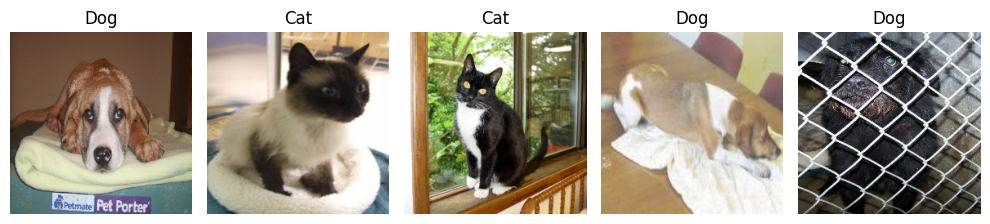

Klasy decyzyjne: ['Cat', 'Dog']


In [9]:
dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names

plt.figure(figsize=(10, 5))

for images, labels in dataset.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()
print(f"Klasy decyzyjne: {class_names}")

### Dane treningowe, walidacyjne i testowe oraz augmentacja danych

In [10]:
# Creating train and validation data

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

train_ds_without_shuffle = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    validation_split=0,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds_without_shuffle = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    validation_split=0,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_without_shuffle = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    validation_split=0,
    image_size=IMG_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

Found 15997 files belonging to 2 classes.
Found 15997 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 4000 files belonging to 2 classes.
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


### ResNet50 - nauka modelu

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/3
    500/Unknown 254s 498ms/step - accuracy: 0.7527 - loss: 0.4890

C:\Users\chosze\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 332s 656ms/step - accuracy: 0.8687 - loss: 0.3121 - val_accuracy: 0.9784 - val_loss: 0.0968
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 326s 653ms/step - accuracy: 0.9640 - loss: 0.1161 - val_accuracy: 0.9846 - val_loss: 0.0589
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 326s 652ms/step - accuracy: 0.9721 - loss: 0.0853 - val_accuracy: 0.9860 - val_loss: 0.0468


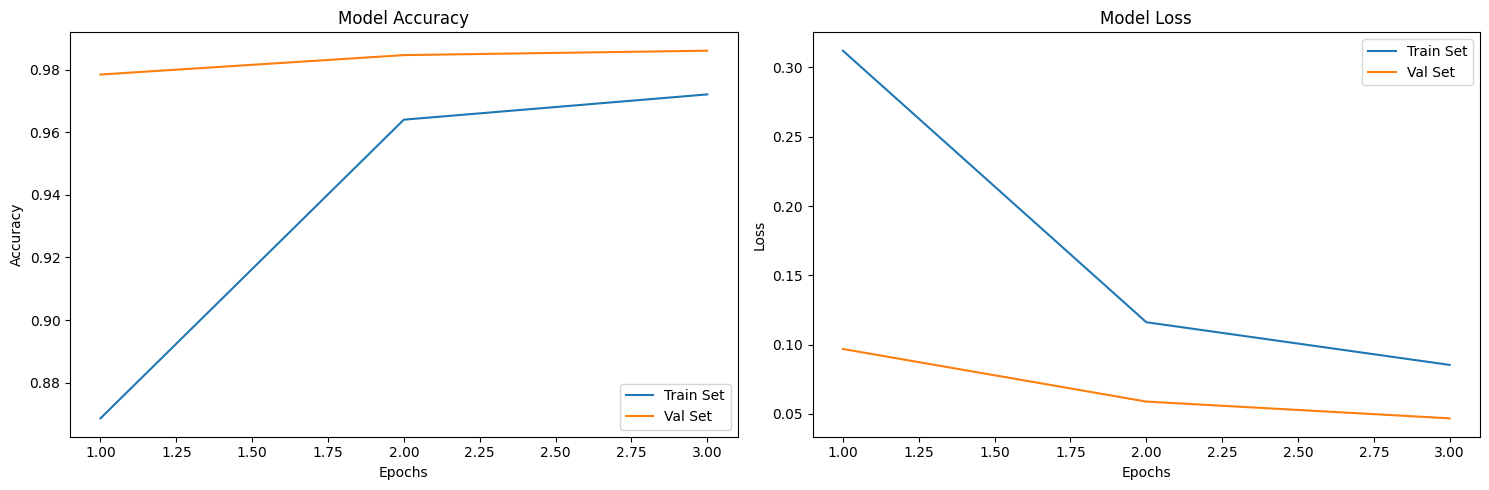

ROC AUC: 0.9989163199999999
Report for validation set:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2500
           1       0.98      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



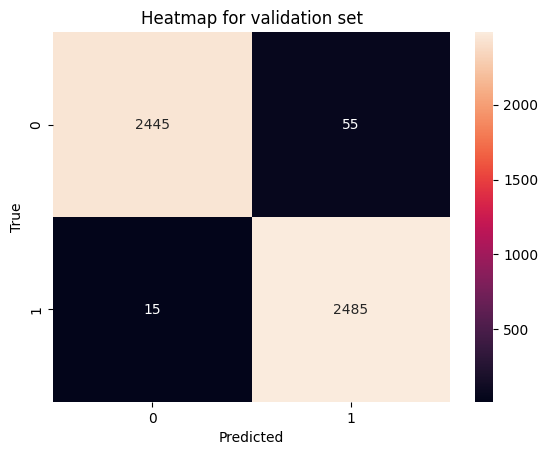

ROC AUC: 0.9983292500000001
Report for test set:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2000
           1       0.98      0.98      0.98      2000

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



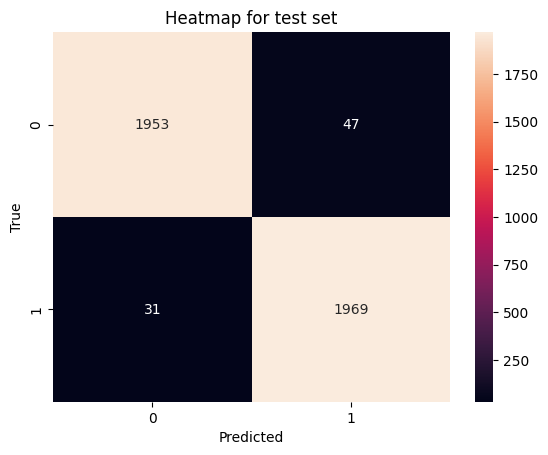

In [11]:
from tensorflow.keras.applications.resnet import preprocess_input, ResNet50

resNet50_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

train_model(resNet50_model, 'ResNet50_model')

### ResNet50 - wynik dla wskazanej próbki

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda (Lambda)                      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


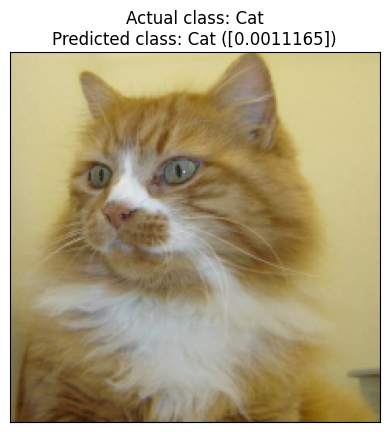

In [12]:
from tensorflow.keras.applications.resnet import preprocess_input

resNet50_model = load_model('ResNet50_model', train_ds_without_shuffle, sample_id)

### ResNet50 - LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

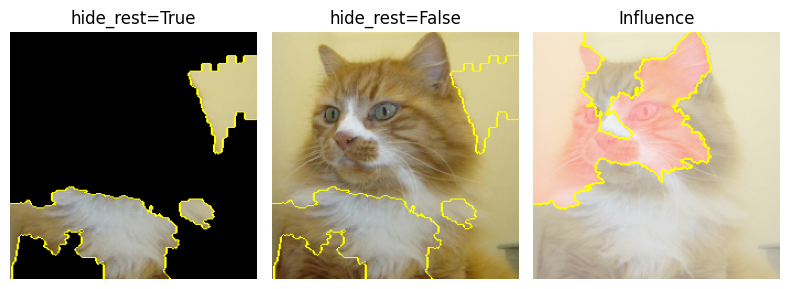

In [13]:
from tensorflow.keras.applications.resnet import preprocess_input

lime(resNet50_model, train_ds_without_shuffle, sample_id)

### ResNet50 - SHAP

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:26, 26.94s/it]                                                                   


<Figure size 800x800 with 0 Axes>

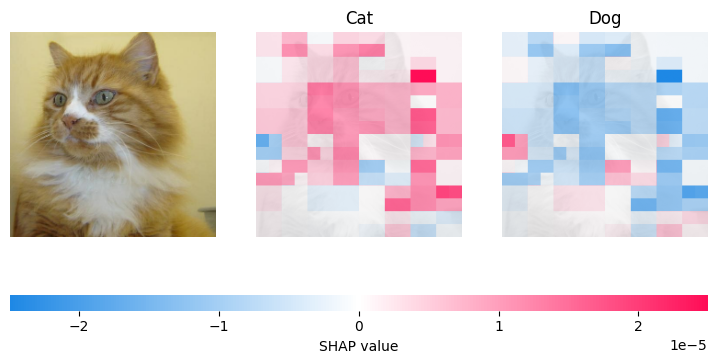

In [14]:
from tensorflow.keras.applications.resnet import preprocess_input

shap_for_images(resNet50_model, train_ds_without_shuffle, sample_id)

### ResNet50 - Grad - CAM

In [14]:
resNet50_model.layers[2].summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: Cat (0.0012)


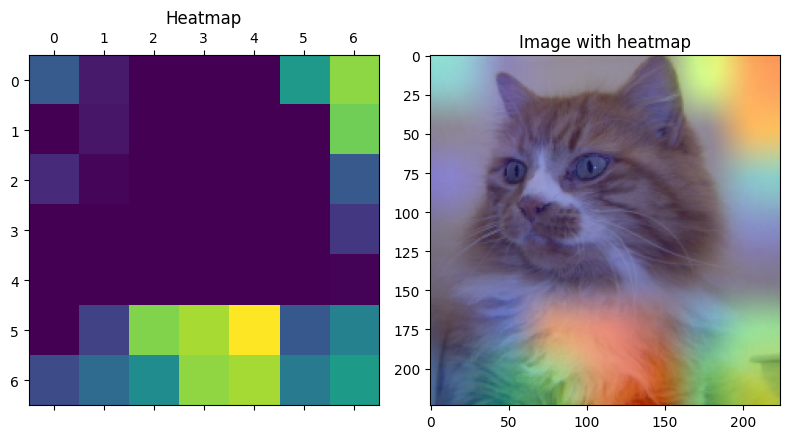

In [15]:
from tensorflow.keras.applications.resnet import preprocess_input

grad_cam(resNet50_model, train_ds_without_shuffle, sample_id, "conv5_block3_3_conv")

### Xception - nauka modelu

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 7, 7, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/3
    500/Unknown 312s 617ms/step - accuracy: 0.8193 - loss: 0.4445

C:\Users\chosze\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 406s 806ms/step - accuracy: 0.9078 - loss: 0.3038 - val_accuracy: 0.9876 - val_loss: 0.1176
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 404s 809ms/step - accuracy: 0.9696 - loss: 0.1219 - val_accuracy: 0.9894 - val_loss: 0.0692
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 401s 803ms/step - accuracy: 0.9717 - loss: 0.0935 - val_accuracy: 0.9898 - val_loss: 0.0523


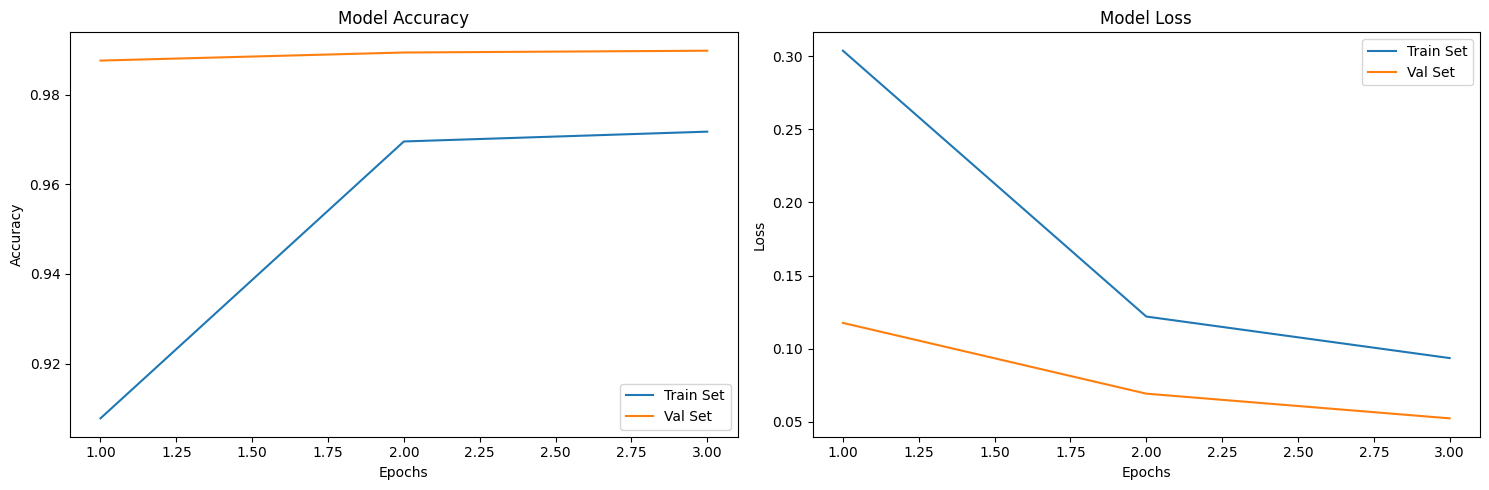

ROC AUC: 0.999216
Report for validation set:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2500
           1       0.99      0.99      0.99      2500

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



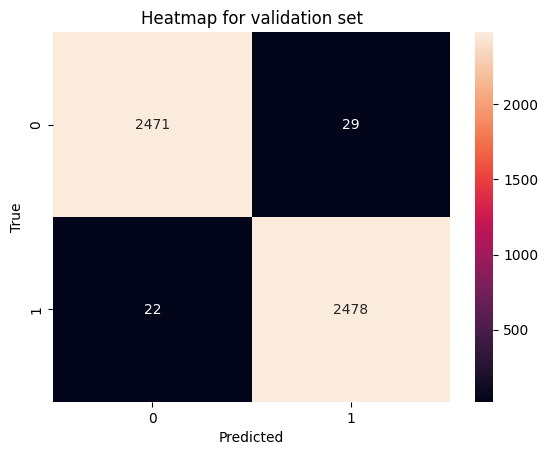

ROC AUC: 0.998721
Report for test set:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2000
           1       0.98      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



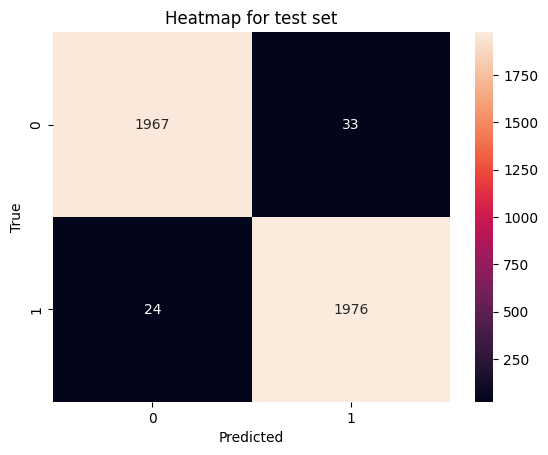

In [16]:
from keras.applications.xception import preprocess_input, Xception

xception_model = Xception(
    weights='imagenet',
    include_top=False, 
    input_shape=IMG_SIZE + (3,)
)

train_model(xception_model, 'Xception_model')

### Xception - wynik dla wskazanej próbki

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ xception (Functional)                │ (None, 7, 7, 2048)          │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


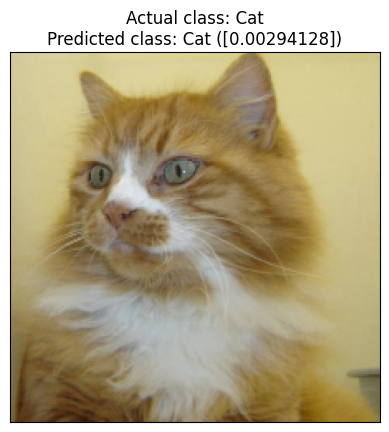

In [17]:
from keras.applications.xception import preprocess_input

xception_model = load_model('xception_model', train_ds_without_shuffle, sample_id)

### Xception- LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 972ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

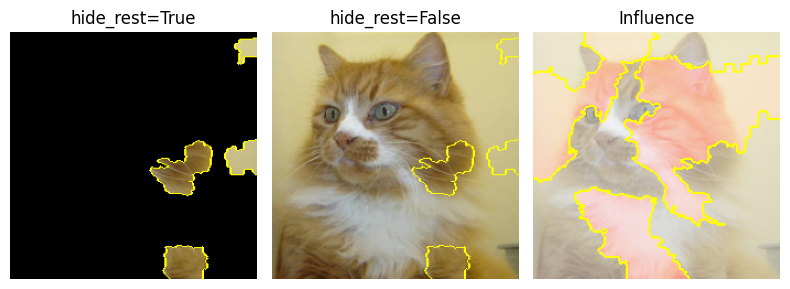

In [18]:
lime(xception_model, train_ds_without_shuffle, sample_id)

### Xception - SHAP

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:22, 22.85s/it]                                                                   


<Figure size 800x800 with 0 Axes>

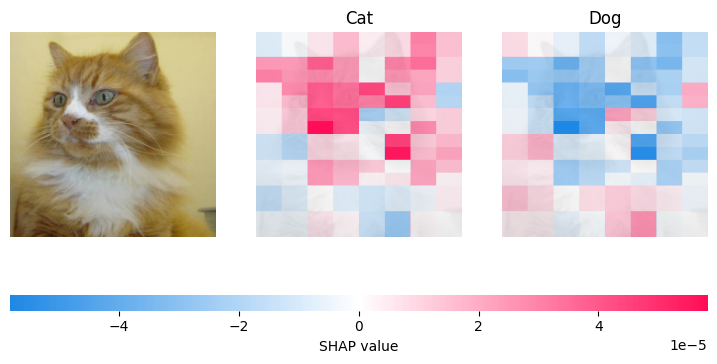

In [19]:
shap_for_images(xception_model, train_ds_without_shuffle, sample_id)

### Xception - Grad - CAM

In [44]:
xception_model.layers[2].summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 111, 111, 32)      │             864 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_bn               │ (None, 111, 111, 32)      │             128 │ block1_conv1[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1_act (Activation) │ (None, 111, 111, 32)      │               0 │ block1_conv1_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 109, 109, 64)      │          18,432 │ block1_conv1_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_bn               │ (None, 109, 109, 64)      │             256 │ block1_conv2[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2_act (Activation) │ (None, 109, 109, 64)      │               0 │ block1_conv2_bn[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1               │ (None, 109, 109, 128)     │           8,768 │ block1_conv2_act[0][0]     │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv1_bn            │ (None, 109, 109, 128)     │             512 │ block2_sepconv1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_act           │ (None, 109, 109, 128)     │               0 │ block2_sepconv1_bn[0][0]   │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2               │ (None, 109, 109, 128)     │          17,536 │ block2_sepconv2_act[0][0]  │
│ (SeparableConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_sepconv2_bn            │ (None, 109, 109, 128)     │             512 │ block2_sepconv2[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 55, 55, 128)       │           8,192 │ block1_conv2_act[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 55, 55, 128)       │               

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
Predicted: Cat (0.0028)


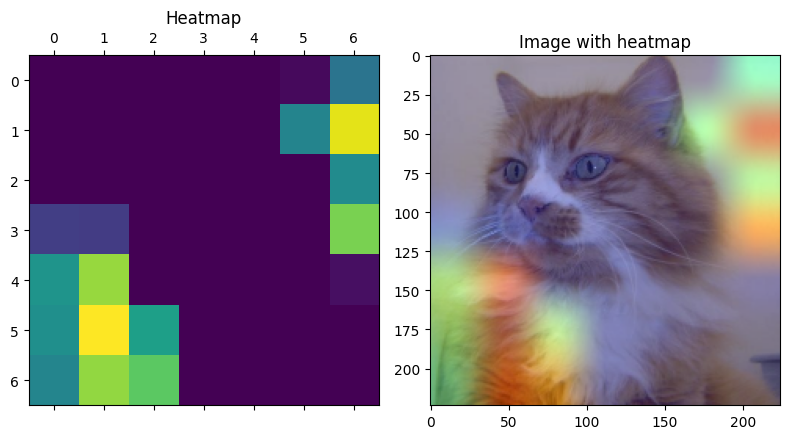

In [20]:
grad_cam(xception_model, train_ds_without_shuffle, sample_id, "block14_sepconv2") 

### VGG - 16 - nauka modelu

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/3
    500/Unknown 685s 1s/step - accuracy: 0.7496 - loss: 1.0203

C:\Users\chosze\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 896s 2s/step - accuracy: 0.7840 - loss: 0.8443 - val_accuracy: 0.9360 - val_loss: 0.2108
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 896s 2s/step - accuracy: 0.8710 - loss: 0.4629 - val_accuracy: 0.9620 - val_loss: 0.1226
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 895s 2s/step - accuracy: 0.8992 - loss: 0.3398 - val_accuracy: 0.9706 - val_loss: 0.0906


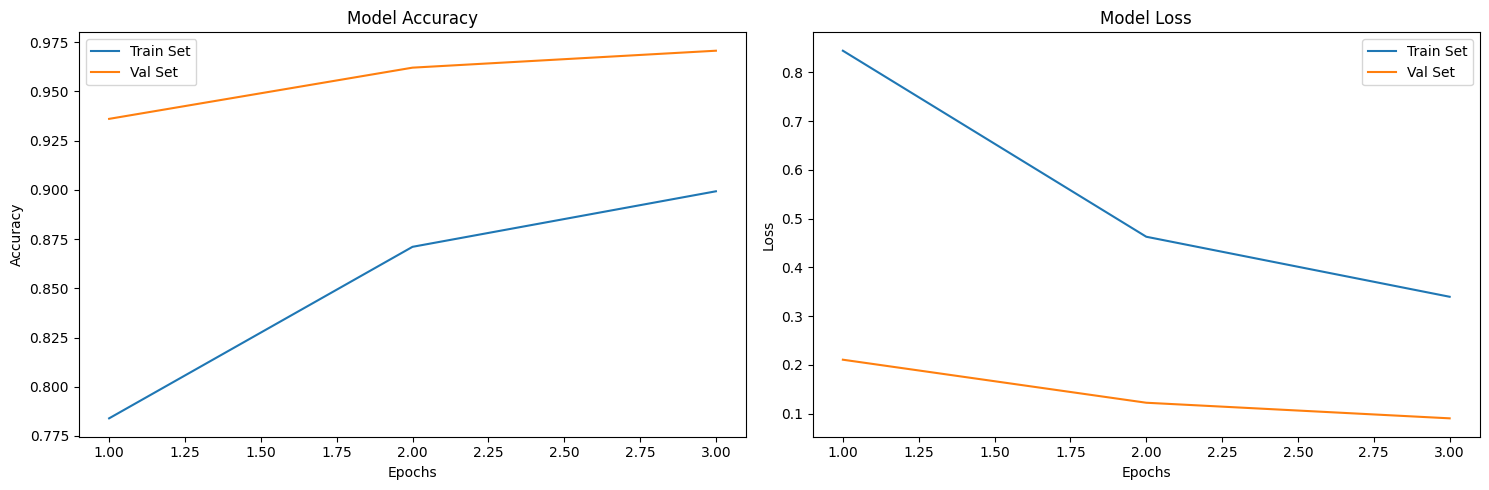

ROC AUC: 0.9963328000000001
Report for validation set:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2500
           1       0.97      0.97      0.97      2500

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000



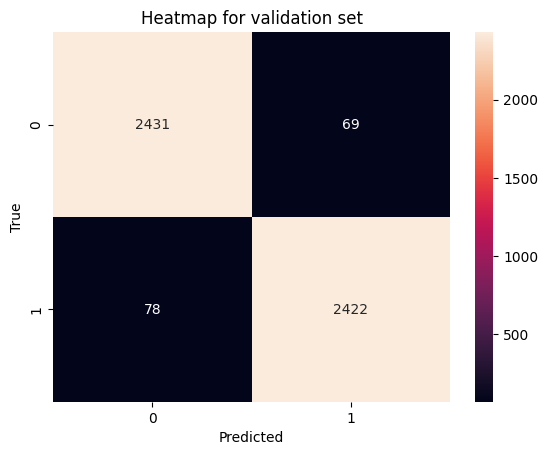

ROC AUC: 0.993945125
Report for test set:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2000
           1       0.97      0.96      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



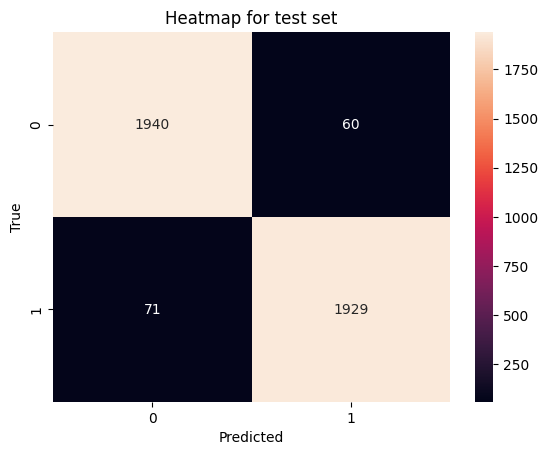

In [21]:
from keras.applications.vgg16 import VGG16, preprocess_input

vgg16_model = VGG16(
    weights='imagenet',
    include_top=False, 
    input_shape=IMG_SIZE + (3,)
)

train_model(vgg16_model, 'VGG_model')

### VGG - 16 wynik dla wskazanej próbki

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


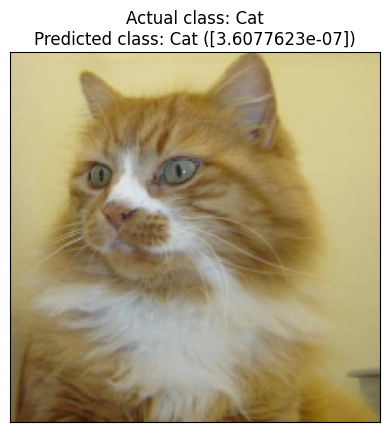

In [22]:
from keras.applications.vgg16 import preprocess_input

vgg16_model = load_model('VGG_model', train_ds_without_shuffle, sample_id)

### VGG - 16 - LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

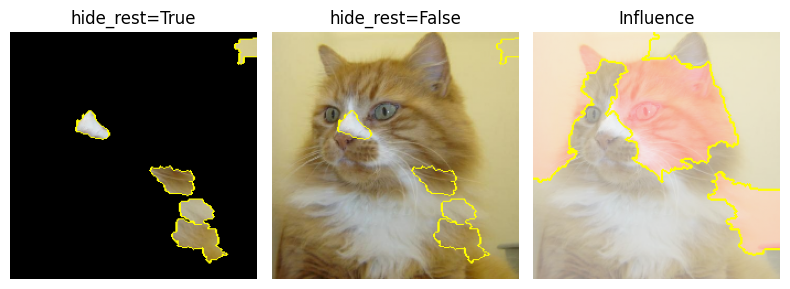

In [23]:
from keras.applications.vgg16 import preprocess_input

lime(vgg16_model, train_ds_without_shuffle, sample_id)

### VGG - 16 - SHAP

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:35, 35.55s/it]                                                                   


<Figure size 800x800 with 0 Axes>

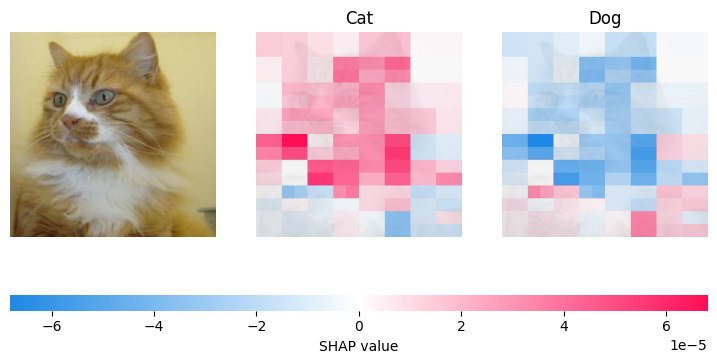

In [24]:
shap_for_images(vgg16_model, train_ds_without_shuffle, sample_id)

### VGG - 16 - Grad - CAM

In [31]:
vgg16_model.layers[2].summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Predicted: Cat (0.0000)


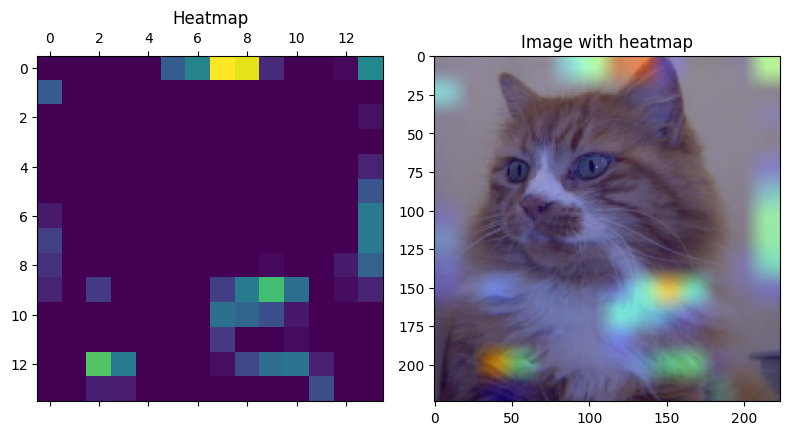

In [25]:
grad_cam(vgg16_model, train_ds_without_shuffle, sample_id, "block5_conv3") 